# 00 — Data Preparation & EDA

This notebook:
1. Clones the repo and sets up paths (Colab-compatible)
2. Loads the pre-processed JSONL splits
3. Provides exploratory analysis of the JTBD classification dataset

**Run locally first**: `python scripts/prepare_dataset.py` → commit → push → then this notebook just loads from `data/processed/`.

**Requirement**: repo must be public on GitHub (no auth needed for clone).

In [3]:
# ── 0. Environment setup (idempotent — safe to re-run) ────────────────────────
import sys, os

try:
    import google.colab
    IN_COLAB = True
    print('Running on Google Colab')
except ImportError:
    IN_COLAB = False
    print('Running locally')

REPO_URL  = 'https://github.com/michaelarutyunov/text-to-lora-demo.git'
REPO_NAME = 'text-to-lora-demo'

if IN_COLAB:
    if not os.path.exists(f'/content/{REPO_NAME}'):
        !git clone {REPO_URL} /content/{REPO_NAME}
    else:
        !cd /content/{REPO_NAME} && git pull

    assert os.path.exists(f'/content/{REPO_NAME}'), \
        'Clone failed — is the repo public? github.com/michaelarutyunov/text-to-lora-demo'
    %cd /content/{REPO_NAME}

    # Install from requirements file (torch pre-installed on Colab — excluded)
    !pip install -q -r requirements_colab.txt
else:
    repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
    os.chdir(repo_root)

if 'src' not in sys.path:
    sys.path.insert(0, 'src')

print(f'Working directory: {os.getcwd()}')

Running on Google Colab
Cloning into '/content/text-to-lora-demo'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 30 (delta 7), reused 27 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 105.34 KiB | 2.45 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/text-to-lora-demo
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.2 MB/s eta 0:00:00:00:0100:01
Working directory: /content/text-to-lora-demo


In [4]:
# ── 1. Load splits ─────────────────────────────────────────────────────────────
from data_utils import load_splits, NODE_TYPES, LABEL2ID

splits = load_splits('data/processed')
train, val, test = splits['train'], splits['val'], splits['test']

print(f'Train: {len(train):4d} examples')
print(f'Val:   {len(val):4d} examples')
print(f'Test:  {len(test):4d} examples')
print(f'Total: {len(train) + len(val) + len(test):4d} examples')

Train:  918 examples
Val:    197 examples
Test:   197 examples
Total: 1312 examples


        node_type  count       pct
       pain_point    527 40.167683
solution_approach    193 14.710366
       gain_point    164 12.500000
    emotional_job    149 11.356707
    job_statement    110  8.384146
      job_context    104  7.926829
      job_trigger     56  4.268293
       social_job      9  0.685976


/tmp/ipykernel_9064/2249738835.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_dist, x='node_type', y='count', ax=ax, palette='Blues_d')
/tmp/ipykernel_9064/2249738835.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')


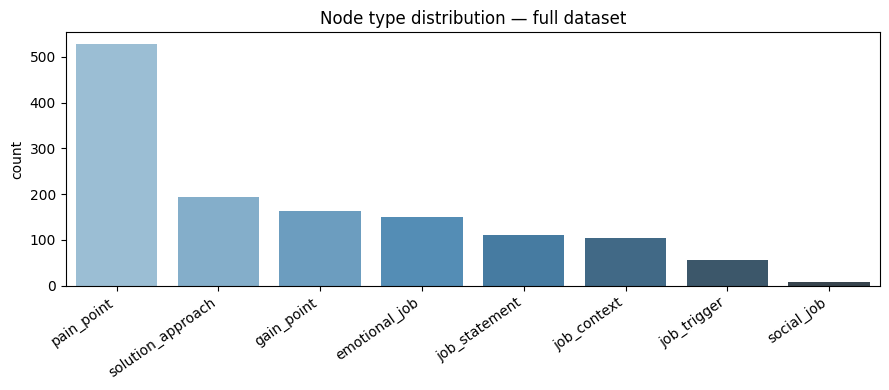


Imbalance ratio (max/min): 58.6x


In [5]:
# ── 2. Class distribution ──────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

all_examples = train + val + test
type_counts = Counter(e['node_type'] for e in all_examples)

df_dist = pd.DataFrame([
    {'node_type': nt, 'count': type_counts.get(nt, 0), 'pct': type_counts.get(nt, 0) / len(all_examples) * 100}
    for nt in NODE_TYPES
]).sort_values('count', ascending=False)

print(df_dist.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=df_dist, x='node_type', y='count', ax=ax, palette='Blues_d')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.set_title('Node type distribution — full dataset')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

max_c = df_dist['count'].max()
min_c = df_dist[df_dist['count'] > 0]['count'].min()
print(f'\nImbalance ratio (max/min): {max_c / min_c:.1f}x')

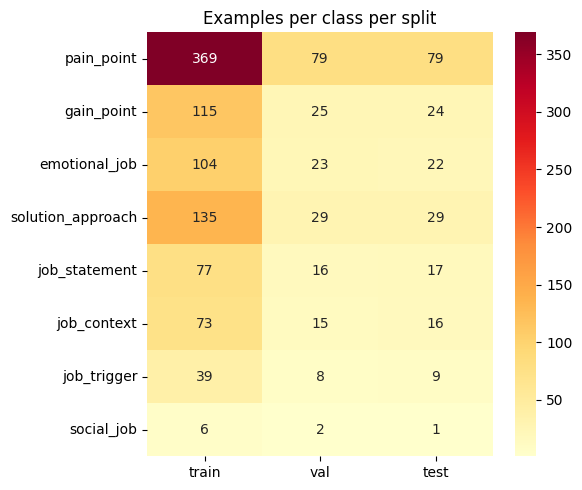

In [6]:
# ── 3. Per-split class distribution heatmap ───────────────────────────────────
split_dists = {}
for split_name, exs in splits.items():
    counts = Counter(e['node_type'] for e in exs)
    split_dists[split_name] = [counts.get(nt, 0) for nt in NODE_TYPES]

df_heat = pd.DataFrame(split_dists, index=NODE_TYPES)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df_heat, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Examples per class per split')
plt.tight_layout()
plt.show()

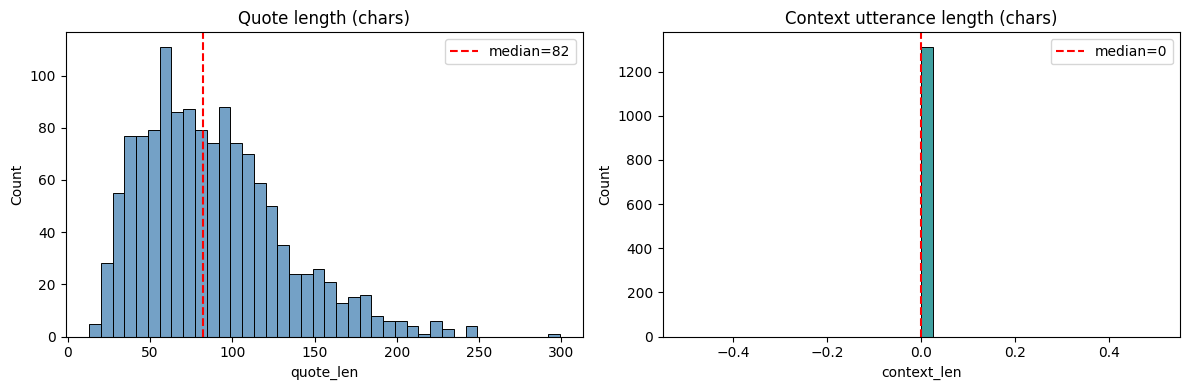


Summary statistics:
       quote_len  context_len
count     1312.0       1312.0
mean        88.4          0.0
std         43.1          0.0
min         13.0          0.0
25%         56.0          0.0
50%         82.0          0.0
75%        112.0          0.0
max        299.0          0.0


In [7]:
# ── 4. Quote and context length distributions ─────────────────────────────────
df_all = pd.DataFrame(all_examples)
df_all['quote_len'] = df_all['quote'].str.len()
df_all['context_len'] = df_all['context'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_all['quote_len'], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Quote length (chars)')
axes[0].axvline(df_all['quote_len'].median(), color='red', linestyle='--',
                label=f'median={df_all["quote_len"].median():.0f}')
axes[0].legend()
sns.histplot(df_all['context_len'], bins=40, ax=axes[1], color='teal')
axes[1].set_title('Context utterance length (chars)')
axes[1].axvline(df_all['context_len'].median(), color='red', linestyle='--',
                label=f'median={df_all["context_len"].median():.0f}')
axes[1].legend()
plt.tight_layout()
plt.show()
print('\nSummary statistics:')
print(df_all[['quote_len', 'context_len']].describe().round(1))

In [8]:
# ── 5. Spot-check examples ────────────────────────────────────────────────────
from data_utils import format_prompt
import random
random.seed(0)
sample = random.sample(train, min(5, len(train)))
for i, ex in enumerate(sample, 1):
    print(f'--- Example {i} [{ex["node_type"]}] ---')
    print(format_prompt(ex))
    print()

--- Example 1 [pain_point] ---
[CONTEXT]: [no context available]
[QUOTE]: not prioritizing time for meal planning
Classify the quote into one of: pain_point | gain_point | emotional_job | solution_approach | job_statement | job_context | job_trigger | social_job
Answer:

--- Example 2 [job_context] ---
[CONTEXT]: [no context available]
[QUOTE]: I've got enough going on — work's unpredictable, my schedule shifts around
Classify the quote into one of: pain_point | gain_point | emotional_job | solution_approach | job_statement | job_context | job_trigger | social_job
Answer:

--- Example 3 [pain_point] ---
[CONTEXT]: [no context available]
[QUOTE]: It's not the app mechanics—it's that I'm trying to solve this problem that feels unsolvable.
Classify the quote into one of: pain_point | gain_point | emotional_job | solution_approach | job_statement | job_context | job_trigger | social_job
Answer:

--- Example 4 [pain_point] ---
[CONTEXT]: [no context available]
[QUOTE]: The thing that keeps 

In [9]:
# ── 6. Missing context audit ──────────────────────────────────────────────────
no_ctx = [e for e in all_examples if not e.get('context', '').strip()]
pct_no_ctx = len(no_ctx) / len(all_examples) * 100
print(f'Examples without context: {len(no_ctx)} ({pct_no_ctx:.1f}%)')
if no_ctx:
    print('\nBreakdown by node_type:')
    for nt, c in Counter(e['node_type'] for e in no_ctx).most_common():
        print(f'  {nt}: {c}')

Examples without context: 1312 (100.0%)

Breakdown by node_type:
  pain_point: 527
  solution_approach: 193
  gain_point: 164
  emotional_job: 149
  job_statement: 110
  job_context: 104
  job_trigger: 56
  social_job: 9
